In [40]:

import sys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


data = np.load("../../../_recordings/2024-06-19--11-58-06_partial-plus-correlator_L6toL8-2/archive.npz")



results = {}

for experiment in data.keys():
    experiment_parameters = data[experiment]["reboot_seed"]["experiment_parameters"][0]
    shape = experiment_parameters["shape"]

    if shape[0] in results:
        results[shape[0]].append(data[experiment])
    else:
        results[shape[0]] = [data[experiment]]

z_order = 7
roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])



lattice_sizes = []

result_keys = list(results.keys())
result_keys.sort()


time_series = {}
tin_data = {}
pp_correlators = {}
average_plaquettes = {}

for shape in result_keys:
    results[shape].sort(key=lambda x: x["reboot_seed"]["experiment_parameters"]["beta"])

    print(shape)
    for res in results[shape]:
        print(res.dtype)


    results[shape] = np.array(results[shape])

    

    rec_shape = results[shape]["ploop_corr_recordings"]["polyakov_loops"].shape

    _,_,number_rec, x_dim, y_dim, z_dim = rec_shape


    loops = results[shape]["ploop_corr_recordings"]["polyakov_loops"]
    loops = roots_of_unity[loops]

    # Tin Data
    temp = loops.sum(axis=(3,4,5))
    tin_snapshot = np.linalg.norm(temp, axis=-1)  
    tin_snapshot = tin_snapshot.sum(axis=(1,2))/(number_rec*x_dim*y_dim*z_dim)
    tin_data[x_dim]= tin_snapshot

    # Time series
    time_serie = loops.sum(axis=(3,4,5)).squeeze(axis=1)/(x_dim*y_dim*z_dim)
    time_series[x_dim] = time_serie

    betas = results[shape]["reboot_seed"]["experiment_parameters"]["beta"].squeeze()

    lattice_sizes.append(x_dim)

    pp_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators"]
    average_plaquettes[x_dim] = results[shape]["ploop_corr_recordings"]["average_plaquette"]


 


# save the data
np.savez("temp/treated_data_plus-2", time_series=time_series, tin_data=tin_data, betas=betas, lattice_sizes=lattice_sizes, pp_correlators=pp_correlators, average_plaquettes=average_plaquettes)
    



6
[('reboot_seed', [('last_state', [('edges', 'u1', (5184,)), ('rng_gen', [('rng_gen_wrapper', 'u1', (16,))]), ('performed_updates', '<u8'), ('accepted_updates', '<u8')]), ('experiment_parameters', [('shape', '<u4', (4,)), ('z_order', '<u4'), ('beta', '<f4'), ('lambda', '<f4'), ('rng_seed', '<u8')])]), ('run_info', [('recordings', '<u4'), ('recording_skip', '<u4'), ('recordings_until_backup', '<u4'), ('backup_number', '<u4'), ('recording_time', '<i8'), ('run_id', '<u4')]), ('ploop_corr_recordings', [('polyakov_loops', 'u1', (100000, 6, 6, 6)), ('polyakov_loop_correlators', '<f4', (100000, 7, 2)), ('pp_correlators', '<f4', (100000, 7, 2)), ('average_plaquette', '<f4', (100000, 2))])]
[('reboot_seed', [('last_state', [('edges', 'u1', (5184,)), ('rng_gen', [('rng_gen_wrapper', 'u1', (16,))]), ('performed_updates', '<u8'), ('accepted_updates', '<u8')]), ('experiment_parameters', [('shape', '<u4', (4,)), ('z_order', '<u4'), ('beta', '<f4'), ('lambda', '<f4'), ('rng_seed', '<u8')])]), ('run_

L=6 mid point correlator: [ 6.0397241e-02 -1.3179781e-05]
L=6 average plaquette: [ 2.45761111e-01 -1.13358365e-05]
-1.2814999e-06


L=8 mid point correlator: [6.0403362e-02 3.6379602e-06]
L=8 average plaquette: [2.4572477e-01 1.3353526e-05]
2.2701919e-05




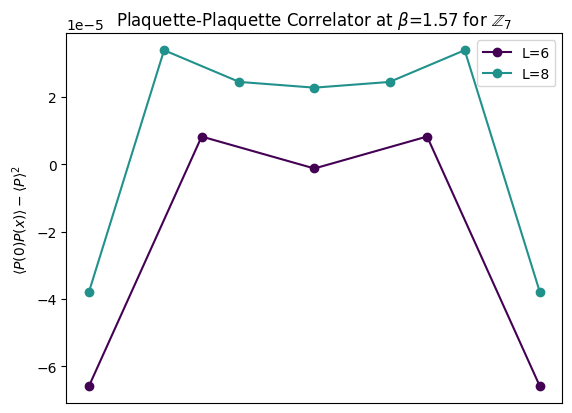

In [45]:

data = np.load("temp/treated_data_plus-2.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()
average_plaquettes = data["average_plaquettes"].item()



fig = plt.figure()



# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=0, vmax=len(pp_correlators.keys()))


which_beta = 0

for (i,key) in enumerate(pp_correlators.keys()):

    # if key != 6:
    #     continue

    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)
    average_plaquette = average_plaquettes[key][which_beta,:,...].squeeze(axis=0)

    color = cmap(norm(i))

    thermalise = 0

    pp_correlator_mean = pp_correlator[thermalise:].mean(axis=0)[:]
    average_plaquette_mean = average_plaquette[thermalise:].mean(axis=0)

    print(f"L={key} mid point correlator: {pp_correlator_mean[len(pp_correlator_mean)//2]}")
    print(f"L={key} average plaquette: {average_plaquette_mean}")

    pp_correlator_mean = pp_correlator_mean[:,0]
    average_plaquette_mean = average_plaquette_mean[0]

   
  

    cutoff = 1
    if cutoff > 0:
        pp_correlator_mean = pp_correlator_mean[cutoff:-cutoff]
    else: 
        pp_correlator_mean = pp_correlator_mean




    pp_correlator_mean = pp_correlator_mean - average_plaquette_mean**2
    print( pp_correlator_mean[len(pp_correlator_mean)//2])
    print("\n")

    # print the middle point
    # print(f"L={key} middle point: {pp_correlator_mean[len(pp_correlator_mean)//2]}")



    Ls = np.arange(len(pp_correlator_mean))
    max_L = np.max(Ls)
    Ls = Ls / max_L

    plt.plot(Ls, pp_correlator_mean, '-o', label=f"L={key}", color=color)

    #plot error bars
    #calculate variance
    variance = pp_correlator.var(axis=0)[:,0]
    variance = variance[cutoff:-cutoff]
    std = np.sqrt(variance/len(pp_correlator))


    # plt.fill_between(Ls, pp_correlator_mean-std, pp_correlator_mean+std, alpha=0.4, color=color)
    # #also plot bars 
    # plt.errorbar(Ls, pp_correlator_mean, yerr=std, fmt='o', color=color)


plt.xticks([])
plt.ylabel(r"$\langle P(0)P(x)\rangle - \langle P \rangle^2$ ")

plt.title(r"Plaquette-Plaquette Correlator at $\beta$=1.57 for $\mathbb{Z}_7$")
plt.legend()

plt.savefig("pp_correlator.pdf")


plt.show()


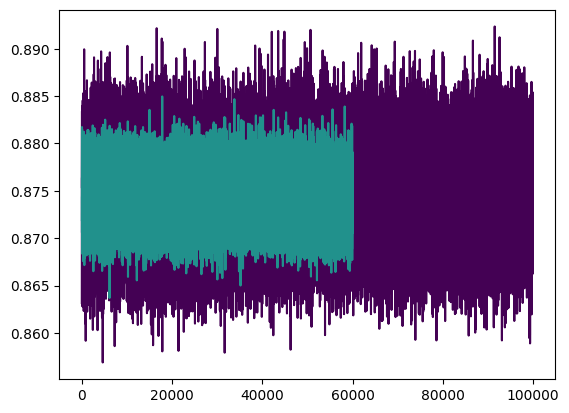

In [42]:
data = np.load("temp/treated_data_plus-2.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()
average_plaquettes = data["average_plaquettes"].item()

fig = plt.figure()



# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=0, vmax=len(pp_correlators.keys()))


which_beta = 4

middle_points = []

for (i,key) in enumerate(pp_correlators.keys()):
  

    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)
    average_plaquette = average_plaquettes[key][which_beta,:,...].squeeze(axis=0)

    color = cmap(norm(i))

    #res = pp_correlator[:,pp_correlator.shape[1]//2,0] #- average_plaquette[:,0]**2
    res =  average_plaquette[:,0]

    # print(key)
    # print(pp_correlator.mean(axis=0)[:,0][pp_correlator.shape[1]//2])
    # print(average_plaquette.mean(axis=0)[0])
    # print("\n")


    middle_points.append(res)


# plot the middle points
for (i, m) in enumerate(middle_points):
    zoom = 50

    L = 1000000

    m = m[2:][zoom:L]
    x = np.arange(len(m))
    color = cmap(norm(i))

    plt.plot(x, m, '-', label=f"L={lattice_sizes[i]}", color=color)
